In [58]:
import json
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Generic ML training boilerplate for tabular data
# Update the config below for your project

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score,
)

In [59]:
# -----------------------------
# Config
# -----------------------------
RANDOM_SEED = 42
DATA_PATH = "urinalysis_tests.csv"        # Change to your dataset path
TARGET_COL = "Diagnosis"               # Change to your target column
MODEL_NAME = "baseline_model16"
TASK = "classification"              # "classification" or "regression"
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(DATA_PATH)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in {DATA_PATH}")

In [60]:
# print all empty rows
df[df.isnull().any(axis=1)]

# delete rows that have empty cells
df = df.dropna()


In [61]:
df.info

<bound method DataFrame.info of       Unnamed: 0    Age  Gender         Color   Transparency   Glucose  \
0              0  76.00  FEMALE  LIGHT YELLOW          CLEAR  NEGATIVE   
1              1   9.00    MALE   DARK YELLOW  SLIGHTLY HAZY  NEGATIVE   
2              2  12.00    MALE  LIGHT YELLOW  SLIGHTLY HAZY  NEGATIVE   
3              3  77.00    MALE         BROWN         CLOUDY  NEGATIVE   
4              4  29.00  FEMALE        YELLOW           HAZY  NEGATIVE   
...          ...    ...     ...           ...            ...       ...   
1431        1431   0.06    MALE        YELLOW          CLEAR  NEGATIVE   
1432        1432  42.00    MALE        YELLOW          CLEAR  NEGATIVE   
1433        1433  47.00  FEMALE   DARK YELLOW          CLEAR  NEGATIVE   
1434        1434  57.00  FEMALE   DARK YELLOW          CLEAR  NEGATIVE   
1435        1435   3.00    MALE        YELLOW          CLEAR  NEGATIVE   

       Protein   pH  Specific Gravity  WBC     RBC Epithelial Cells  \
0     NE

In [62]:
# rename the unnamed column to "number"
df.rename(columns={"Unnamed: 0": "number"}, inplace=True)

In [63]:
# print all values in the "WBC" column
print(df["WBC"].unique())

def midpoint_range_to_int(value):
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    # Normalize special values
    if value in {"TNTC", "LOADED"}:
        return 100  # merged to LOADED
    if value == ">100":
        return 100
    if value == ">50":
        return 50

    if "-" in value:
        low, high = value.split("-", 1)
        try:
            return int(round((int(low.strip()) + int(high.strip())) / 2))
        except ValueError:
            return None

    try:
        return int(value)
    except ValueError:
        return None


df["WBC"] = df["WBC"].map(midpoint_range_to_int)
df["WBC"] = pd.to_numeric(df["WBC"], errors="coerce").astype("Int64")
print(df["WBC"].unique())

<StringArray>
[   '1-3',    '0-3',    '5-8',    '1-4',    '3-5',  '70-75',    '0-2',
    '1-2',    '2-4',    '6-8',   '8-10',  '10-12',    '0-1',    '4-6',
  '20-25',  '25-30',  '18-25',    '3-6', 'LOADED',  '28-30',    '5-7',
  '12-15',  '15-17',  '30-35',   '8-12',    '2-3',  '35-40',  '50-55',
  '11-15',  '48-55',  '45-50',  '12-14',  '14-16',  '17-20',  '55-58',
   '9-11',    '>50',  '15-20',  '20-22',  '18-20',    '7-9',   'TNTC',
    '2-5',  '34-36',  '30-32',  '23-25',   '5-10',   '9-15',  '13-15',
    '4-8',  '11-14',  '10-16',   '7-15',    '7-8',    '0-4',  '15-22',
  '15-21',   '>100',   '7-10',  '15-28',    '1-5',    '4-5',    '2-7',
    '3-7',  '10-15',    '4-7',  '79-85',  '28-35',   '3-10',    '5-6',
    '3-4',  '15-18',   '4-10',  '10-18',   '8-11']
Length: 75, dtype: str
<IntegerArray>
[  2,   6,   4,  72,   1,   3,   7,   9,  11,   0,   5,  22,  28, 100,  29,
  14,  16,  32,  10,  38,  52,  13,  48,  15,  18,  56,  50,  21,  19,   8,
  35,  31,  24,  12,  82]
Length: 3

In [64]:
drop_cols = ['Age', 'pH', 'Specific Gravity', 'Mucous Threads', 'RBC', 'Glucose', 'Color', 'Amorphous Urates', 'Protein', 'Gender', "number"]
X = df.drop(columns=[TARGET_COL] + drop_cols)
label_map = {"NEGATIVE": 0, "POSITIVE": 1}
y = df[TARGET_COL].map(label_map)

# Optional: quick validation
if X.empty:
    raise ValueError("Feature matrix is empty. Check your dataset.")
if len(X) != len(y):
    raise ValueError("Feature and target lengths do not match.")


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold


# -----------------------------
# Split data
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# -----------------------------
# Preprocessing
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])


# -----------------------------
# Model and pipeline
# -----------------------------
model = XGBClassifier(
    objective="binary:logistic", 
    eval_metric="logloss", 
    random_state=RANDOM_SEED, 
    n_jobs=1, 
    verbosity=0,
    )

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("model", model),
])

# -----------------------------
# Grid search
# -----------------------------
param_grid = {
    "model__n_estimators": [100, 200, 250, 300, 350, 400, 450, 500], 
    "model__max_depth": [3, 6, 9, 12, 15], 
    "model__learning_rate": [0.05, 0.01, 0.5, 0.1], 
    "model__subsample": [0.8, 1.0], 
    "model__colsample_bytree": [0.8, 1.0],
    }

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED
    ),

    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV F1: {grid_search.best_score_:.4f}")

# Use the tuned pipeline in subsequent cells
pipeline = grid_search.best_estimator_
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]

Fitting 5 folds for each of 640 candidates, totalling 3200 fits
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV F1: 0.6256


Evaluation metrics:
  accuracy: 0.9616724738675958
  precision_positive: 0.6666666666666666
  recall_positive: 0.625
  f1_positive: 0.6451612903225806

Saved model to: artifacts\baseline_model16.pkl
Saved metrics to: artifacts\baseline_model16_metrics.json


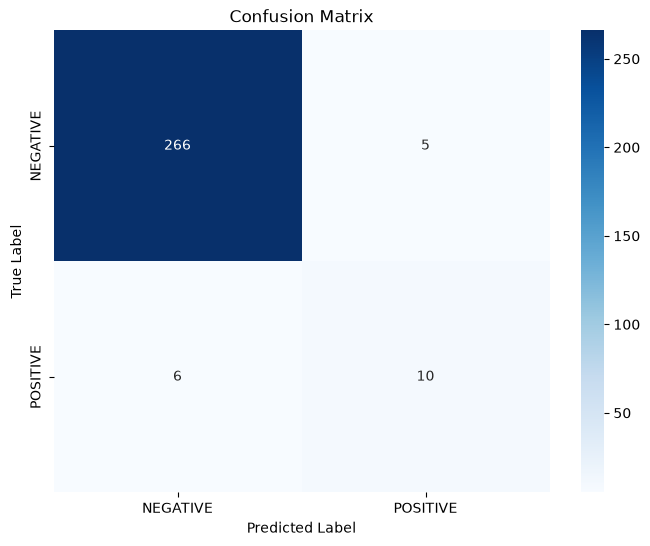

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------
# Train
# -----------------------------
pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_val)[:, 1]

# -----------------------------
# Evaluate
# -----------------------------
y_pred = pipeline.predict(X_val)


metrics = {
    "accuracy": accuracy_score(y_val, y_pred),
    "precision_positive": precision_score(y_val, y_pred, pos_label=1, zero_division=0),
    "recall_positive": recall_score(y_val, y_pred, pos_label=1, zero_division=0),
    "f1_positive": f1_score(y_val, y_pred, pos_label=1, zero_division=0),
}

print("Evaluation metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

# -----------------------------
# Save model
# -----------------------------
model_path = ARTIFACTS_DIR / f"{MODEL_NAME}.pkl"
with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)

metrics_path = ARTIFACTS_DIR / f"{MODEL_NAME}_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nSaved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")

import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NEGATIVE', 'POSITIVE'], 
            yticklabels=['NEGATIVE', 'POSITIVE'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()